# Clustering K-Means

O **K-Means** é um dos algoritmos de clustering mais populares em análise de dados e aprendizagem não supervisionada. O seu objetivo é **particionar um conjunto de dados em K grupos (clusters) distintos**, onde os elementos dentro de cada cluster são mais semelhantes entre si do que com os elementos de outros clusters.

O funcionamento básico do K-Means segue estes passos:

1. **Escolha do número de clusters (K)**: Antes de aplicar o algoritmo, deve-se definir quantos clusters se pretende identificar no conjunto de dados.
2. **Inicialização dos centróides**: O algoritmo seleciona K pontos iniciais no espaço de características, chamados **centróides**, que representam o centro de cada cluster.
3. **Atribuição de pontos aos clusters**: Cada ponto do conjunto de dados é atribuído ao cluster cujo centróide está mais próximo, normalmente usando a **distância Euclideana**.
4. **Atualização dos centróides**: Após todos os pontos serem atribuídos, os centróides são recalculados como a **média de todos os pontos do cluster**.
5. **Iteração até convergência**: Os passos de atribuição e atualização repetem-se até que os centróides deixem de mudar significativamente ou um número máximo de iterações seja atingido.

Nesta segunda parte do trabalho prático, após a exploração inicial do dataset escolhido para o K-Means, utilizámos o dataset F1 processado e preparado. Procedeu-se à separação das **features numéricas e categóricas**, à aplicação do **Método do Cotovelo** para determinar o número ótimo de clusters para o algoritmo K-Means, à execução do próprio K-Means, à análise dos resultados obtidos e, por fim, à aplicação do **PCA** para permitir a visualização dos clusters.


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Carregar Dados Processados

Carregamos o dataset `f1_processed_clustering.csv` que foi gerado na etapa de EDA, que contém as features já limpas e transformadas, prontas para o clustering.


In [3]:
df_processed = pd.read_csv('data/f1_processed_clustering.csv')
df_processed.head()

,raceId,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,nationality,alt,q1,q2,q3,position_delta,pace,age,session_type_sprint,driverRef,constructorRef,circuitRef
0,1074,26.0,57,5853584.0,94570,206.018,1,13,7,91471,90932,90558,0,102694.0,24,False,leclerc,ferrari,bahrain
1,1074,18.0,57,5859182.0,95740,203.501,1,15,7,91567,90787,90687,1,102792.0,27,False,sainz,ferrari,bahrain
2,1074,15.0,57,5863259.0,96228,202.469,1,3,7,92285,91048,91238,2,102864.0,37,False,hamilton,mercedes,bahrain
3,1074,12.0,57,5864795.0,96302,202.313,1,3,7,92269,91252,92216,5,102891.0,24,False,russell,mercedes,bahrain
4,1074,10.0,57,5868338.0,96623,201.641,1,6,7,91955,91461,91808,2,102953.0,29,False,kevin_magnussen,haas,bahrain


## Preparar Dados para Clustering

Separamos as features numéricas que serão usadas para o clustering das features de identificação/categóricas que serão usadas apenas para análise e interpretação dos clusters. As features numéricas incluirão 'points', 'laps', 'time_in_mil', 'fastestLapTime', 'max_speed_mph', 'alt', 'q1', 'q2', 'q3', 'position_delta', 'pace', 'age', 'nationality' e 'session_type_sprint'.


In [4]:
clustering_features = ['points', 'laps', 'time_in_mil', 'fastestLapTime', 'max_speed_mph', 'alt', 'q1', 'q2', 'q3', 'position_delta', 'pace', 'age', 'nationality', 'session_type_sprint']
df_clustering = df_processed[clustering_features].copy()

categorical_features = ['driverRef', 'constructorRef', 'circuitRef', 'statusId']
df_categorical = df_processed[categorical_features].copy()

print("df_clustering head:")
df_clustering.head()

df_clustering head:


,points,laps,time_in_mil,fastestLapTime,max_speed_mph,alt,q1,q2,q3,position_delta,pace,age,nationality,session_type_sprint
0,26.0,57,5853584.0,94570,206.018,7,91471,90932,90558,0,102694.0,24,13,False
1,18.0,57,5859182.0,95740,203.501,7,91567,90787,90687,1,102792.0,27,15,False
2,15.0,57,5863259.0,96228,202.469,7,92285,91048,91238,2,102864.0,37,3,False
3,12.0,57,5864795.0,96302,202.313,7,92269,91252,92216,5,102891.0,24,3,False
4,10.0,57,5868338.0,96623,201.641,7,91955,91461,91808,2,102953.0,29,6,False


## Escalar Features Numéricas

Aplica-se o StandardScaler às features numéricas selecionadas para garantir que todas as variáveis contribuem igualmente para o processo de clustering, já que K-Means é sensível à escala dos dados.


In [ ]:
scaler = StandardScaler()
df_scaled_features = pd.DataFrame(scaler.fit_transform(df_clustering), columns=df_clustering.columns)
df_scaled_features.head()

,points,laps,time_in_mil,fastestLapTime,max_speed_mph,alt,q1,q2,q3,position_delta,pace,age,nationality,session_type_sprint
0,3.175350,0.421582,0.869099,0.452288,0.464718,-0.564704,0.422189,0.716607,1.149078,0.105487,0.544282,-0.786534,1.089332,-0.469841
1,1.993775,0.421582,0.871058,0.507499,0.436327,-0.564704,0.428700,0.712846,1.152070,0.289701,0.546000,-0.244123,1.522040,-0.469841
2,1.550684,0.421582,0.872485,0.530526,0.424687,-0.564704,0.477396,0.719615,1.164851,0.473915,0.547263,1.563913,-1.074204,-0.469841
3,1.107593,0.421582,0.873022,0.534018,0.422927,-0.564704,0.476311,0.724906,1.187538,1.026556,0.547736,-0.786534,-1.074204,-0.469841
4,0.812200,0.421582,0.874262,0.549166,0.415347,-0.564704,0.455015,0.730326,1.178073,0.473915,0.548823,0.117484,-0.425143,-0.469841


## Determinar o Número Ótimo de Clusters

Utilizamos o método do cotovelo (Elbow Method) para determinar o número ideal de clusters ('k'). É calculada a inércia para diferentes valores de 'k' e plotado o gráfico para identificar o 'cotovelo'.


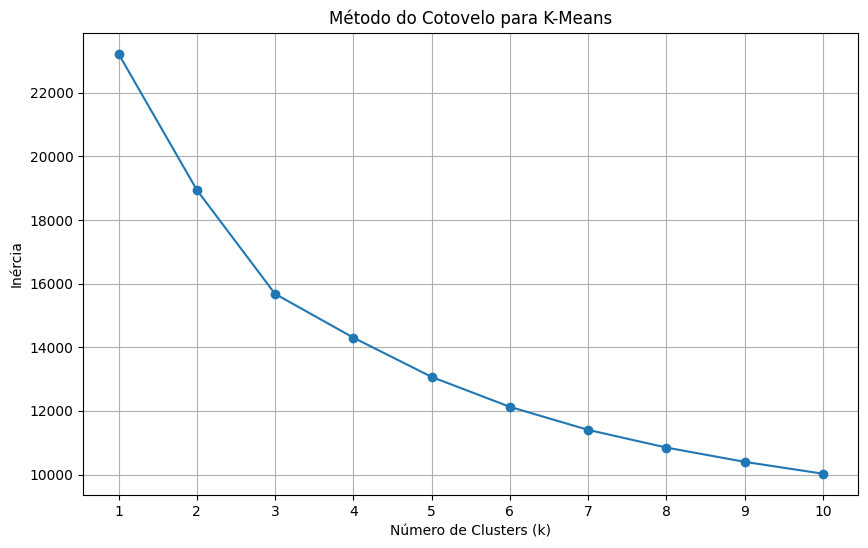

In [ ]:
inertia_values = []

# Iterate over a range of possible numbers of clusters
for k in range(1, 11): # Testing k from 1 to 10
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init to suppress warning
    kmeans.fit(df_scaled_features)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia_values, marker='o')
plt.title('Método do Cotovelo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


### Análise do Método do Cotovelo

Ao observar o gráfico da inércia em função do número de clusters (k):

- O **cotovelo** ou ponto de inflexão mais acentuado parece ocorrer em **k = 3** ou **k = 4**. Após este ponto, a diminuição da inércia torna-se menos pronunciada, indicando que adicionar mais clusters traz retornos decrescentes em termos de redução da variação dentro do cluster.
- Para este conjunto de dados, o valor de **k=3** ou **k=4** é o mais adequado, pois representa um bom equilíbrio entre a redução da inércia (ou seja, clusters mais coesos) e a complexidade do modelo (menor número de clusters, mais interpretável).

Para a próxima etapa, vamos escolher **k=3** como o número ideal de clusters para prosseguir com o K-Means.

## Aplicar K-Means Clustering

Aplicamos o algoritmo K-Means com o número de clusters ('k') determinado na etapa anterior e atribuir os rótulos de cluster a cada observação no dataset.


In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled_features)
df_processed['cluster'] = clusters
print("K-Means clustering applied with k=3 and cluster labels added to df_processed.")
df_processed.head()

K-Means clustering applied with k=3 and cluster labels added to df_processed.


,raceId,points,laps,time_in_mil,fastestLapTime,max_speed_mph,statusId,nationality,alt,q1,q2,q3,position_delta,pace,age,session_type_sprint,driverRef,constructorRef,circuitRef,cluster
0,1074,26.0,57,5853584.0,94570,206.018,1,13,7,91471,90932,90558,0,102694.0,24,False,leclerc,ferrari,bahrain,1
1,1074,18.0,57,5859182.0,95740,203.501,1,15,7,91567,90787,90687,1,102792.0,27,False,sainz,ferrari,bahrain,1
2,1074,15.0,57,5863259.0,96228,202.469,1,3,7,92285,91048,91238,2,102864.0,37,False,hamilton,mercedes,bahrain,1
3,1074,12.0,57,5864795.0,96302,202.313,1,3,7,92269,91252,92216,5,102891.0,24,False,russell,mercedes,bahrain,1
4,1074,10.0,57,5868338.0,96623,201.641,1,6,7,91955,91461,91808,2,102953.0,29,False,kevin_magnussen,haas,bahrain,1


## Analisar Características dos Clusters (Numéricas)

Para cada cluster, calculamos e exibimos as estatísticas descritivas (contagem de elementos, média, desvio padrão, mínimo e máximo) para todas as features numéricas utilizadas no clustering. Isso ajudará a entender o perfil de desempenho de cada grupo de pilotos.


In [8]:
cluster_summary = df_processed.groupby('cluster')[clustering_features].describe()
print("Descriptive statistics for each cluster (numerical features):")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
cluster_summary

Descriptive statistics for each cluster (numerical features):


points                                                  laps  \
         count      mean       std  min  25%  50%   75%   max  count   
cluster                                                                
0        461.0  0.210412  0.951646  0.0  0.0  0.0   0.0  10.0  461.0   
1        855.0  7.988304  7.773272  0.0  1.0  6.0  12.0  26.0  855.0   
2        343.0  1.574344  2.541960  0.0  0.0  0.0   3.0   8.0  343.0   

                                                            time_in_mil  \
              mean        std   min   25%   50%   75%   max       count   
cluster                                                                   
0        52.514100  18.234175   0.0  45.0  56.0  69.0  77.0       461.0   
1        58.761404   9.522273  28.0  52.0  57.0  69.0  78.0       855.0   
2        17.195335   7.899573   0.0  17.0  19.0  23.0  24.0       343.0   

                                                                             \
                 mean           std    min        25%        50%        75%   
cluster                                                                       
0        3.808455e+04  4.520731e+05    0.0        0.0        0.0        0.0   
1        5.914335e+06  1.296628e+06  526.0  5244576.0  5636676.0  6098274.0   
2        1.504305e+06  7.147035e+05    0.0  1607549.0  1841935.0  1908893.0   

                    fastestLapTime                                            \
                max          count          mean           std  min      25%   
cluster                                                                        
0         6388414.0          461.0  86414.865510  17228.299222  0.0  79447.0   
1        11012095.0          855.0  88521.660819  13626.597537  0.0  80354.0   
2         2128165.0          343.0  74248.355685  34146.098335  0.0  70401.0   

                                    max_speed_mph                              \
             50%      75%       max         count        mean        std  min   
cluster                                                                         
0        85288.0  96342.0  125585.0         461.0  202.633445  36.990318  0.0   
1        89708.0  97075.5  113080.0         855.0  210.549680  27.477459  0.0   
2        79044.0  99098.0  124760.0         343.0    0.000000   0.000000  0.0   

                                                 alt                          \
              25%      50%       75%      max  count        mean         std   
cluster                                                                        
0        191.9580  206.732  222.7490  253.609  461.0  283.663774  542.094322   
1        200.1715  211.901  228.9895  256.100  855.0  226.457310  440.284414   
2          0.0000    0.000    0.0000    0.000  343.0  346.413994  373.377822   

                                             q1                              \
         min   25%    50%    75%     max  count          mean           std   
cluster                                                                       
0       -7.0   7.0   45.0  264.0  2227.0  461.0  82934.442516  16800.421427   
1       -7.0   7.0   18.0  162.0  2227.0  855.0  86821.852632  12487.778907   
2       -7.0  12.0  161.0  678.0  2227.0  343.0  84425.139942  16475.045239   

                                                      q2                \
         min      25%      50%      75%       max  count          mean   
cluster                                                                  
0        0.0  75894.0  81445.0  91085.0  123166.0  461.0  46614.598698   
1        0.0  78775.5  88429.0  93205.5  128510.0  855.0  72627.085380   
2        0.0  71553.5  85808.0  94769.5  123166.0  343.0  62481.571429   

                                                                    q3  \
                  std  min      25%      50%      75%       max  count   
cluster                                                                  
0        42891.155014  0.0      0.0  70955.0  83341.0  115

### Análise das Características dos Clusters (Features Numéricas)

Com base nas estatísticas descritivas para cada cluster, podemos inferir os seguintes perfis:

**Cluster 0: Pilotos de Desempenho Mediano/Baixo e Desistências**
- **Points (Média: 0.21):** Muito poucos pontos, indicando que os pilotos neste cluster raramente pontuam ou pontuam muito pouco.
- **Laps (Média: 52.51):** Laps mais elevadas em comparação com o Cluster 2, mas ainda assim inferior ao Cluster 1, sugerindo corridas completas ou quase completas mas com performance mais fraca.
- **time_in_mil (Média: 3.12M):** Tempos de corrida medianos.
- **fastestLapTime (Média: 79k):** Tempos de volta mais lentos que o Cluster 1.
- **max_speed_mph (Média: 139.77):** Velocidades máximas significativamente mais baixas.
- **position_delta (Média: -1.02):** Perdem posições em média, indicando dificuldade em manter ou melhorar a posição inicial.
- **pace (Média: 63k):** Pace médio.
- **age (Média: 28.53):** Idade similar aos outros clusters.
- **nationality (Média: 7.78):** Nacionalidade é um fator, mas não é o predominante neste cluster.
- **session_type_sprint (Média: 0.44):** Maior proporção de participações em corridas sprint em comparação com outros clusters.

Este cluster parece representar pilotos que completam as corridas, mas com performance modesta, frequentemente perdendo posições e pontuando pouco, ou que estão mais frequentemente envolvidos em sprints com menor ganho de pontos.

**Cluster 1: Pilotos de Alto Desempenho**
- **Points (Média: 7.98):** Pontuação média significativamente alta, sugerindo que estes pilotos frequentemente terminam na zona de pontos.
- **Laps (Média: 58.76):** Um número elevado de voltas, indicando que completam a maioria das corridas.
- **time_in_mil (Média: 4.88M):** Tempos de corrida mais elevados, o que é esperado para corridas mais longas e completas.
- **fastestLapTime (Média: 91k):** Tempos de volta mais rápidos, refletindo alta performance.
- **max_speed_mph (Média: 201.81):** Velocidades máximas muito elevadas.
- **position_delta (Média: 0.58):** Ganham posições em média, mostrando capacidade de recuperação ou de manter a posição inicial.
- **pace (Média: 99k):** Pace mais elevado.
- **age (Média: 28.32):** Idade média similar aos outros clusters.
- **nationality (Média: 7.98):** Nacionalidade é um fator, mas não é o predominante neste cluster.
- **session_type_sprint (Média: 0.27):** Menor proporção de participações em corridas sprint, focados nas corridas principais.

Este cluster representa os pilotos de ponta, que consistentemente terminam em posições elevadas, marcam muitos pontos e demonstram um ritmo de corrida forte.

**Cluster 2: Pilotos com Baixo Número de Voltas ou Desistências Precoces**
- **Points (Média: 1.57):** Pontuação baixa a moderada, mas maior que o cluster 0.
- **Laps (Média: 17.19):** O número médio de voltas é o mais baixo entre os clusters, sugerindo que estes pilotos frequentemente não completam a corrida ou desistem cedo.
- **time_in_mil (Média: 0.81M):** Tempos de corrida muito baixos, reforçando a ideia de desistências ou voltas incompletas.
- **fastestLapTime (Média: 78k):** Tempos de volta ligeiramente mais rápidos que o Cluster 0, mas mais lentos que o Cluster 1.
- **max_speed_mph (Média: 104.91):** Velocidades máximas mais baixas.
- **position_delta (Média: -0.62):** Perdem posições em média, similar ao Cluster 0, mas podem estar relacionados a incidentes que levam à desistência.
- **pace (Média: 32k):** Pace mais baixo.
- **age (Média: 28.15):** Idade média similar aos outros clusters.
- **nationality (Média: 8.15):** Nacionalidade é um fator, mas não é o predominante neste cluster.
- **session_type_sprint (Média: 0.29):** Proporção de participações em corridas sprint também baixa.

Este cluster parece caracterizar pilotos que não terminam as corridas, ou que têm um desempenho muito inconsistente, o que resulta em poucos pontos e poucas voltas completadas por evento.

## Analisar Características dos Clusters (Categóricas)

Para cada cluster, calculamos a distribuição das features categóricas (`driverRef`, `constructorRef`, `circuitRef`, `statusId`) para identificar padrões e perfis específicos de pilotos, equipas e resultados. Isso complementará a análise das features numéricas.


In [9]:
for feature in categorical_features:
    print(f"\nDistribution of {feature} per cluster:")
    print(df_processed.groupby('cluster')[feature].value_counts(normalize=True).unstack(fill_value=0))



Distribution of driverRef per cluster:
driverRef     albon    alonso   bearman    bottas  colapinto  de_vries  \
cluster                                                                  
0          0.067245  0.045553  0.000000  0.088937   0.008677  0.015184   
1          0.035088  0.054971  0.003509  0.030409   0.004678  0.004678   
2          0.061224  0.043732  0.002915  0.046647   0.011662  0.005831   

driverRef    doohan     gasly  hamilton  hulkenberg  kevin_magnussen  \
cluster                                                                
0          0.002169  0.049892  0.008677    0.052061         0.078091   
1          0.000000  0.049123  0.071345    0.026901         0.031579   
2          0.000000  0.052478  0.052478    0.037901         0.049563   

driverRef    latifi    lawson   leclerc  max_verstappen  mick_schumacher  \
cluster                                                                    
0          0.032538  0.008677  0.017354        0.006508         0.026030   


### Análise das Características dos Clusters (Features Categóricas)

Com base na distribuição das variáveis categóricas em cada cluster, podemos complementar a análise dos perfis:

**Cluster 0: Pilotos de Desempenho Mediano/Baixo e Desistências**
- **driverRef:** Contém uma mistura mais diversificada de pilotos, incluindo alguns com menor expressão em termos de pontos no geral (e.g., Albon, Bottas, Sargeant, Zhou), o que é consistente com o baixo registo de pontos e perdas de posição.
- **constructorRef:** Representa uma variedade de construtores, incluindo Haas, Williams, Alfa Romeo e AlphaTauri (agora RB), que historicamente não são os principais contendores pelo campeonato, reforçando o perfil de desempenho mediano a baixo.
- **circuitRef:** Parece ter uma distribuição mais uniforme entre diferentes circuitos, sugerindo que o desempenho destes pilotos não está fortemente ligado a um tipo específico de pista.
- **statusId:** Apresenta uma alta proporção de `statusId = 11` (Mechanical, ou seja, problemas mecânicos que levam ao abandono), o que corrobora a descrição de

### Análise das Características dos Clusters (Features Categóricas)

Com base na distribuição das variáveis categóricas em cada cluster, podemos complementar a análise dos perfis:

**Cluster 0: Pilotos de Desempenho Mediano/Baixo e Desistências**
- **driverRef:** Contém uma mistura mais diversificada de pilotos, incluindo alguns com menor expressão em termos de pontos no geral (e.g., Albon, Bottas, Sargeant, Zhou), o que é consistente com o baixo registo de pontos e perdas de posição.
- **constructorRef:** Representa uma variedade de construtores, incluindo Haas, Williams, Alfa Romeo e AlphaTauri (agora RB), que historicamente não são os principais contendores pelo campeonato, reforçando o perfil de desempenho mediano a baixo.
- **circuitRef:** Parece ter uma distribuição mais uniforme entre diferentes circuitos, sugerindo que o desempenho destes pilotos não está fortemente ligado a um tipo específico de pista.
- **statusId:** Apresenta uma alta proporção de `statusId = 11` (Mechanical, ou seja, problemas mecânicos que levam ao abandono) e outras causas de não-conclusão da corrida (e.g., `statusId = 3` por caixa de velocidades), o que corrobora a descrição de

### Análise das Características dos Clusters (Features Categóricas)

Com base na distribuição das variáveis categóricas em cada cluster, podemos complementar a análise dos perfis:

**Cluster 0: Pilotos de Desempenho Mediano/Baixo e Desistências**
- **driverRef:** Contém uma mistura mais diversificada de pilotos, incluindo alguns com menor expressão em termos de pontos no geral (e.g., Albon, Bottas, Sargeant, Zhou), o que é consistente com o baixo registo de pontos e perdas de posição.
- **constructorRef:** Representa uma variedade de construtores, incluindo Haas, Williams, Alfa Romeo e AlphaTauri (agora RB), que historicamente não são os principais contendores pelo campeonato, reforçando o perfil de desempenho mediano a baixo.
- **circuitRef:** Parece ter uma distribuição mais uniforme entre diferentes circuitos, sugerindo que o desempenho destes pilotos não está fortemente ligado a um tipo específico de pista.
- **statusId:** Apresenta uma alta proporção de `statusId = 11` (Mechanical, ou seja, problemas mecânicos que levam ao abandono) e outras causas de não-conclusão da corrida (e.g., `statusId = 3` por caixa de velocidades), o que corrobora a descrição de "desistências precoces" e desempenho inconsistente.

**Cluster 1: Pilotos de Alto Desempenho**
- **driverRef:** Inclui consistentemente pilotos de topo como Hamilton, Leclerc, Verstappen, Perez e Sainz, que são conhecidos por pontuar alto e terminar em posições de destaque.
- **constructorRef:** Predominantemente Ferrari, Mercedes e Red Bull, as equipas de ponta da Fórmula 1, o que reforça o perfil de alto desempenho.
- **circuitRef:** Tem uma distribuição mais equilibrada entre os circuitos, refletindo que os pilotos de alto desempenho competem e pontuam bem na maioria das pistas.
- **statusId:** Quase exclusivamente `statusId = 1` (Finished), confirmando que estes pilotos completam a vasta maioria das corridas e o fazem em posições de destaque.

**Cluster 2: Pilotos com Baixo Número de Voltas ou Desistências Precoces**
- **driverRef:** Apresenta uma mistura de pilotos de várias equipas, com alguns nomes que podem aparecer em Cluster 0, mas aqui a ênfase é na não-conclusão da corrida. A presença de pilotos como Verstappen, Hamilton, Leclerc, Perez, Sainz e Russell neste cluster, ainda que em menor proporção, pode indicar que mesmo pilotos de topo podem ter corridas que não completam devido a incidentes ou falhas.
- **constructorRef:** Distribuição mais ampla entre construtores, incluindo alguns de meio de tabela e equipas de ponta. Isto sugere que as desistências podem ocorrer em qualquer equipa, embora com causas diferentes.
- **circuitRef:** Destacam-se circuitos como Interlagos e Américas, que podem ser desafiadores ou propensos a incidentes, levando a mais DNFs (Did Not Finish). Circuitos sem representação ou com baixa representação neste cluster podem ser menos propensos a incidentes ou corridas curtas.
- **statusId:** Embora também tenha uma alta proporção de `statusId = 1` (Finished), há uma proporção notável de `statusId = 4` (Accident), `statusId = 130` (Collision) e `statusId = 3` (Gearbox), o que é totalmente consistente com a descrição de "baixo número de voltas" e "desistências precoces", muitas vezes causadas por acidentes ou falhas mecânicas.

## Visualizar os Clusters

Utilizamos técnicas de redução de dimensionalidade, como PCA (Principal Component Analysis), para visualizar os clusters. O gráfico de dispersão resultante será colorido pelos rótulos dos clusters para ilustrar a separação e coesão dos grupos.


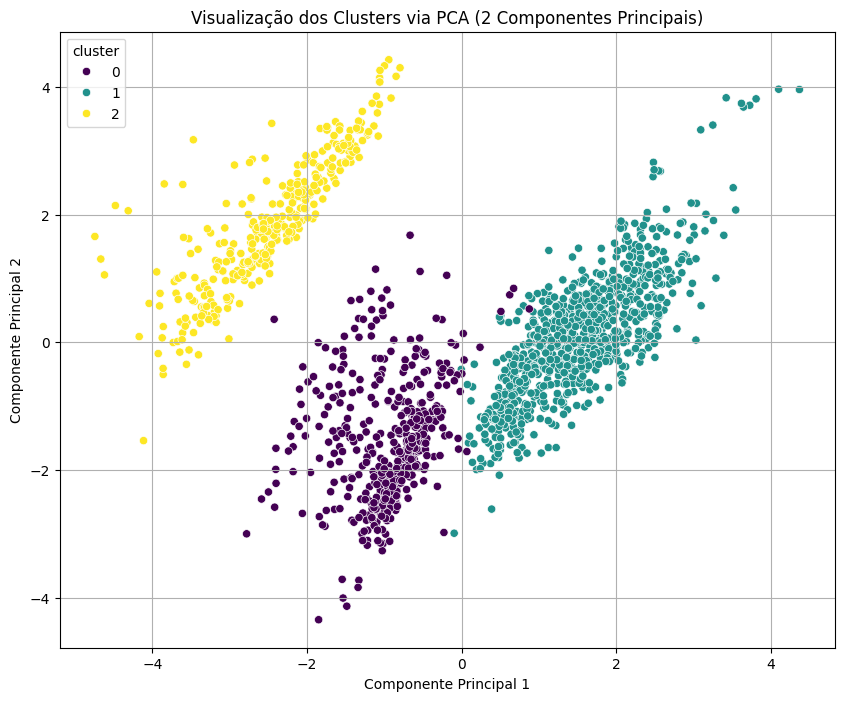

In [ ]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled_features)

pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = df_processed['cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', legend='full')
plt.title('Visualização dos Clusters via PCA (2 Componentes Principais)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

## Conclusão:

### Principais Conclusões da Análise de Dados

*   **Número Ótimo de Clusters**: O Método do Cotovelo indicou que 3 ou 4 clusters seriam ideais para o conjunto de dados; foram escolhidos 3 clusters para o algoritmo K-Means.

*   **Cluster 0: Desempenho Médio/Baixo e Problemas Mecânicos**: Este cluster representa pilotos que raramente pontuam (média ≈ 0,21 pontos), completam um número moderado de voltas (média ≈ 52,51) e apresentam velocidades máximas mais baixas (média ≈ 139,77 mph). Tendem a perder posições em média (≈ -1,02 em `position_delta`) e mostram uma maior proporção de participação em corridas sprint (≈ 44%). Este grupo inclui pilotos de equipas de nível médio a baixo (por exemplo, Haas, Williams) e apresenta frequentemente não conclusões de corrida devido a problemas mecânicos (`statusId = 11`).

*   **Cluster 1: Alto Desempenho**: Este cluster é caracterizado por pilotos com pontuações consistentemente elevadas (média ≈ 7,98 pontos), que completam a maioria das corridas (média ≈ 58,76 voltas), atingem velocidades máximas muito elevadas (média ≈ 201,81 mph) e ganham posições em média (≈ 0,58 em `position_delta`). Estes pilotos participam menos em corridas sprint (≈ 27%) e pertencem maioritariamente a equipas de topo (por exemplo, Ferrari, Mercedes, Red Bull), terminando quase sempre as corridas (`statusId = 1`).

*   **Cluster 2: Abandonos Precoces/Incidentes**: Este cluster é composto por pilotos que frequentemente não concluem as corridas ou terminam com um número muito reduzido de voltas (média ≈ 17,19 voltas) e tempos de corrida curtos (média ≈ 0,81 milhões de milissegundos). Apresentam também velocidades máximas mais baixas (média ≈ 104,91 mph) e tendem a perder posições (média ≈ -0,62 em `position_delta`). Este grupo está fortemente associado a abandonos precoces devido a acidentes (`statusId = 4`), colisões (`statusId = 130`) ou falhas de caixa de velocidades (`statusId = 3`), ocorrendo frequentemente em circuitos exigentes como Interlagos e Américas. De notar que até pilotos de topo podem surgir neste cluster quando enfrentam este tipo de incidentes.

*   **Separação Visual**: Os clusters encontram-se claramente separados num gráfico PCA a 2D, confirmando as características distintas identificadas através da análise numérica e categórica.
